In [1]:
# utils
import os 
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
# torch
import torch
import glob
from pathlib import Path
import torch.optim as optim
from torchinfo import summary
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision import models, datasets

#Remove Warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [3]:
train_dir = r"D:\Users\DEBJIT DAS\brain-tumor-detection-using-mri\brain\Training"
test_dir = r"D:\Users\DEBJIT DAS\brain-tumor-detection-using-mri\brain\Testing"
train_dir,test_dir

('D:\\Users\\DEBJIT DAS\\brain-tumor-detection-using-mri\\brain\\Training',
 'D:\\Users\\DEBJIT DAS\\brain-tumor-detection-using-mri\\brain\\Testing')

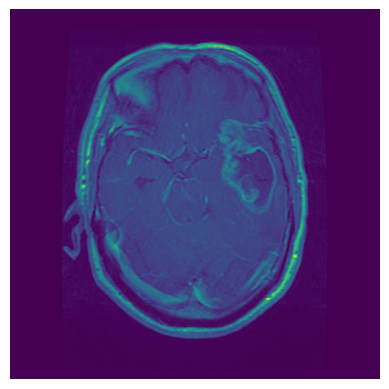

In [4]:
image = Image.open(r"D:\Users\DEBJIT DAS\brain-tumor-detection-using-mri\brain\Testing\glioma\Te-gl_6.jpg")
plt.imshow(image)
plt.axis("off")
plt.show()

In [5]:
categories = os.listdir(train_dir)
print(categories)

['glioma', 'meningioma', 'notumor', 'pituitary']


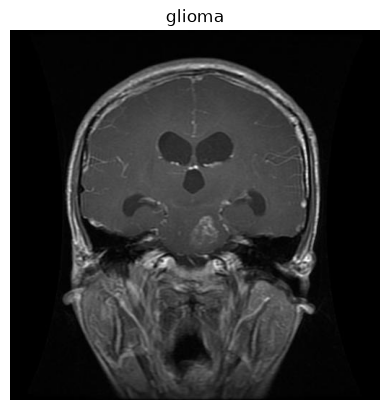

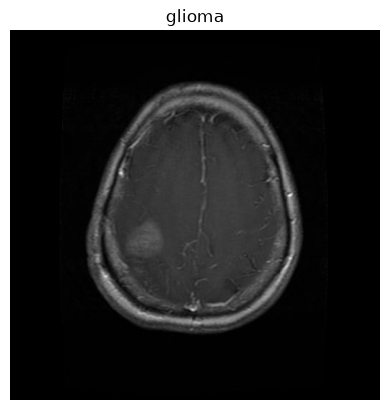

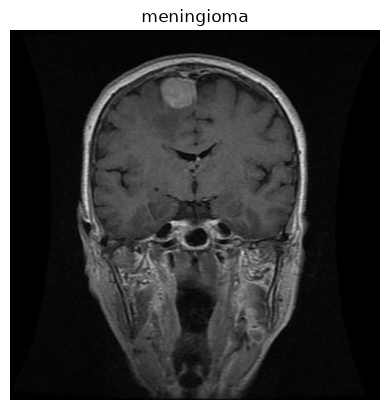

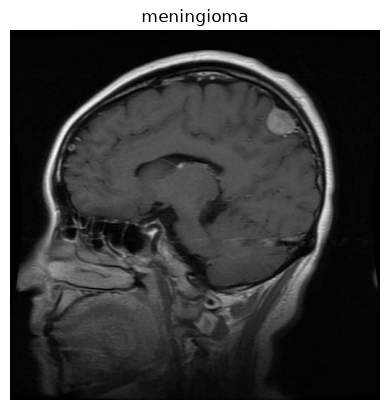

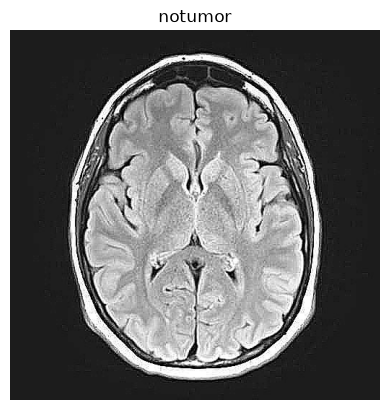

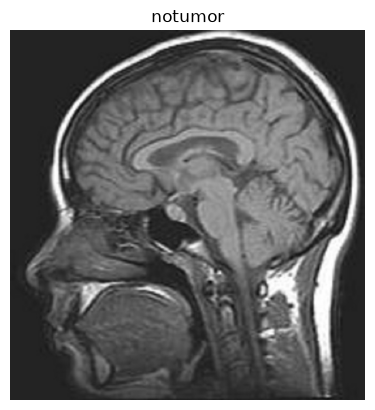

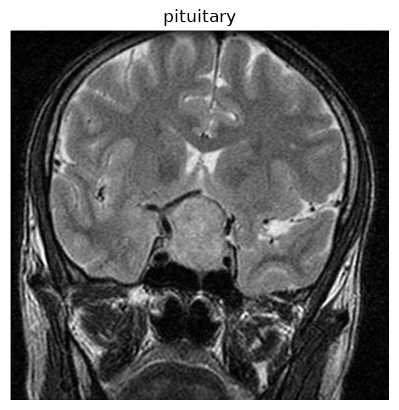

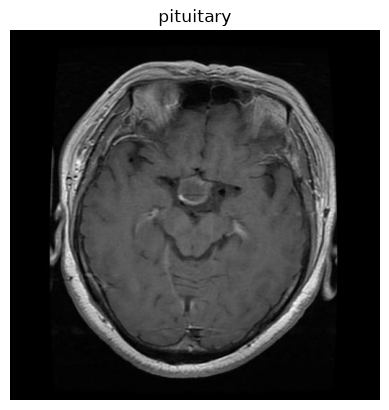

In [6]:


categories = os.listdir(train_dir)

for category in categories:
    folder = os.path.join(train_dir, category)

    images = random.sample(os.listdir(folder), 2)

    for image_name in images:
        image = Image.open(os.path.join(folder, image_name))

        plt.imshow(image, cmap="gray")
        plt.title(category)
        plt.axis("off")
        plt.show()

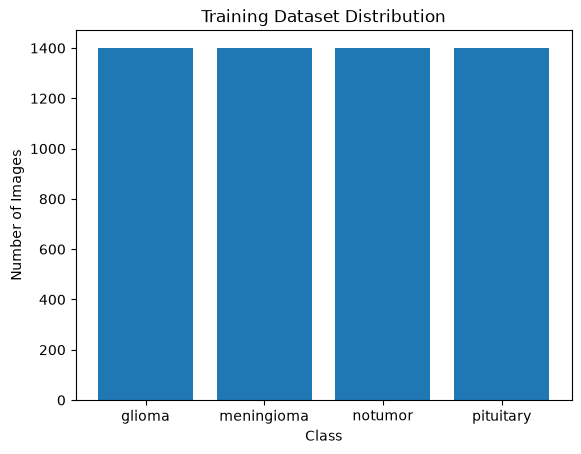

In [7]:
import os
import matplotlib.pyplot as plt

def plot_distribution():
    counts = []

    for category in categories:
        folder = os.path.join(train_dir, category)
        count = len(os.listdir(folder))
        counts.append(count)

    plt.bar(categories, counts)
    plt.xlabel("Class")
    plt.ylabel("Number of Images")
    plt.title("Training Dataset Distribution")
    plt.show()

plot_distribution()

In [8]:
for category in categories:
    folder = os.path.join(train_dir, category)
    print(category, ":", len(os.listdir(folder)))

glioma : 1400
meningioma : 1400
notumor : 1400
pituitary : 1400


Image path : D:\Users\DEBJIT DAS\brain-tumor-detection-using-mri\brain\Training\pituitary\Tr-pi_673.jpg
Image Class : pituitary
Image Height : 512
Image Width : 512


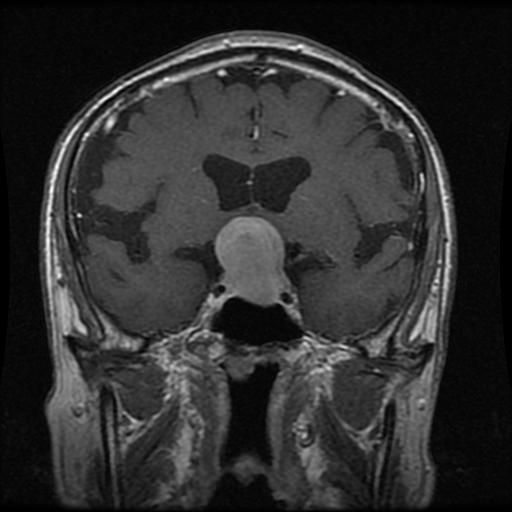

In [9]:
random.seed(42)
image_path_list = glob.glob(
    r'D:\Users\DEBJIT DAS\brain-tumor-detection-using-mri\brain\Training\*/*.jpg'
    
)
random_image_path = random.choice(image_path_list)
image_class = Path(random_image_path).parent.stem



img = Image.open(random_image_path)
print(f"Image path : {random_image_path}")
print(f"Image Class : {image_class}")
print(f"Image Height : {img.height}")
print(f"Image Width : {img.width}")
img


In [10]:
image_width = 128
image_height = 128

image_size = (image_width,image_height)

transform_images = transforms.Compose([
    transforms.Resize(size=image_size),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])

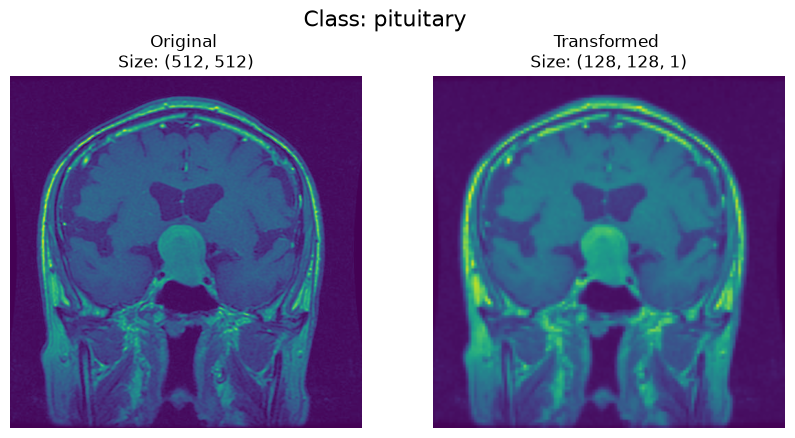

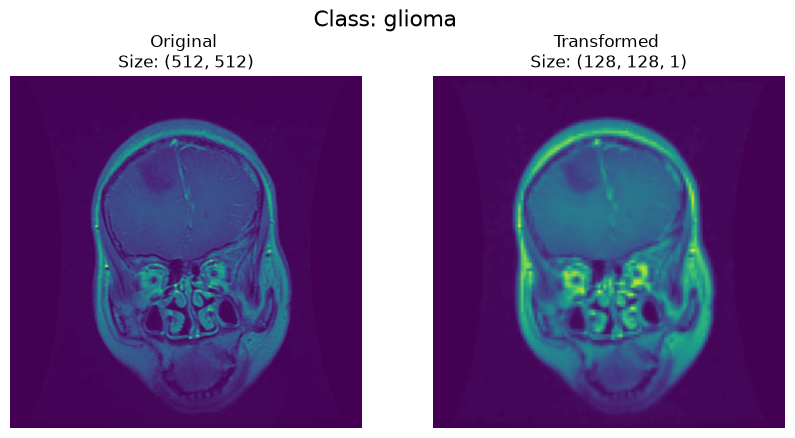

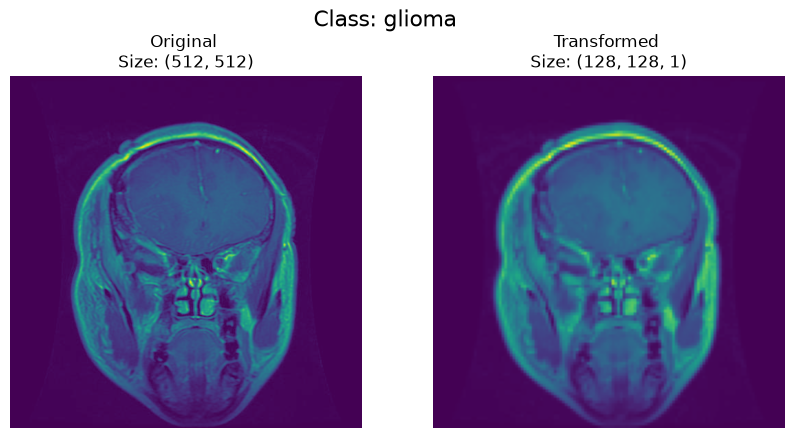

In [11]:

def transform_all_images(image_paths, transform, n=3,seed = 42):
    random.seed(42)
    sampled_paths = random.sample(image_paths, k=min(n, len(image_paths)))
    for img_path in sampled_paths:
        with Image.open(img_path) as f:
            fig, ax = plt.subplots(1, 2, figsize=(10, 5))
            ax[0].imshow(f)
            ax[0].set_title(f"Original \nSize: {f.size}")
            ax[0].axis("off")

            transformed = transform(f)  
            transformed = transformed.permute(1, 2, 0).numpy()  
            ax[1].imshow(transformed)
            ax[1].set_title(f"Transformed \nSize: {transformed.shape}")
            ax[1].axis("off")

            fig.suptitle(f"Class: {Path(img_path).parent.stem}", fontsize=16)
            plt.show()

transform_all_images(image_path_list, transform=transform_images, n=3)

In [12]:
train_data = datasets.ImageFolder(root=train_dir, transform=transform_images,target_transform=None)
test_data = datasets.ImageFolder(root=test_dir, transform=transform_images)
print(f"Train Data {train_data}\n Test Data {test_data}")

Train Data Dataset ImageFolder
    Number of datapoints: 5600
    Root location: D:\Users\DEBJIT DAS\brain-tumor-detection-using-mri\brain\Training
    StandardTransform
Transform: Compose(
               Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
           )
 Test Data Dataset ImageFolder
    Number of datapoints: 1600
    Root location: D:\Users\DEBJIT DAS\brain-tumor-detection-using-mri\brain\Testing
    StandardTransform
Transform: Compose(
               Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
           )


In [13]:
print(f"Class name : {train_data.classes}")
print(f"Class name : {train_data.class_to_idx}")
print(f"The Lenght of Traning and Test Data Set  :",len(train_data),len(test_data))

Class name : ['glioma', 'meningioma', 'notumor', 'pituitary']
Class name : {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
The Lenght of Traning and Test Data Set  : 5600 1600


In [14]:
img, label = train_data[0]
print(f"Image Tensor: {img}")
print(f"Image Shape: {img.shape}")
print(f"Image DataType: {img.dtype}")
print(f"Image label: {label}")
print(f" Label datatype : {label}")

Image Tensor: tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]])
Image Shape: torch.Size([3, 128, 128])
Image DataType: torch.float32
Image label: 0
 Label datatype : 0


In [15]:
num_of_workers = os.cpu_count()
train_loader = DataLoader(train_data,batch_size=32,shuffle=True,num_workers=num_of_workers)
test_loader = DataLoader(test_data,batch_size=32,shuffle=False,num_workers=num_of_workers)
train_loader,test_loader

(<torch.utils.data.dataloader.DataLoader at 0x1b493ac7650>,
 <torch.utils.data.dataloader.DataLoader at 0x1b495bd3050>)

In [16]:
img, label = next(iter(train_loader))
print(f"Image shape {img.shape}")
print(f"Label shape: {label}")

Image shape torch.Size([32, 3, 128, 128])
Label shape: tensor([3, 2, 0, 3, 0, 2, 2, 0, 2, 1, 1, 1, 1, 3, 0, 2, 0, 1, 0, 1, 3, 0, 2, 2,
        1, 2, 1, 2, 3, 2, 2, 0])


In [17]:
image_height = 224
image_width = 224 
image_size = (image_height,image_width) 


train_augmentation = transforms.Compose([

   transforms.Resize(size= image_size),
   transforms.RandomHorizontalFlip(),
   transforms.TrivialAugmentWide(),
   transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
   transforms.ColorJitter(brightness=(0.8, 1.2)),
   transforms.RandomRotation(10),
   transforms.ToTensor(),
   transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_augmentation = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [18]:
train_data_augmentation = datasets.ImageFolder(train_dir,transform=train_augmentation)
test_data_augmentation = datasets.ImageFolder(test_dir,transform=test_augmentation)

In [19]:
from torch.utils.data import random_split, DataLoader

# Split training data into 80% training and 20% validation
train_size = int(0.8 * len(train_data_augmentation))
val_size = len(train_data_augmentation) - train_size

train_dataset, val_dataset = random_split(
    train_data_augmentation,
    [train_size, val_size]
)

# Training DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

# Validation DataLoader
val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))

Training images: 4480
Validation images: 1120


In [20]:
train_augmented_loader = DataLoader(train_data_augmentation,batch_size=32,shuffle=True,num_workers=num_of_workers,pin_memory=True)
test_augmented_loader = DataLoader(test_data_augmentation,batch_size=32,shuffle=False,num_workers=num_of_workers,pin_memory=True)
train_augmented_loader,test_augmented_loader

(<torch.utils.data.dataloader.DataLoader at 0x1b496f20a90>,
 <torch.utils.data.dataloader.DataLoader at 0x1b4985c2650>)

In [21]:
torch.manual_seed(42)

In [22]:
class ImageClassifier(nn.Module):
    def __init__(self):
        super().__init__()

        
        self.conv_layer_1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(kernel_size=2),
            nn.Dropout(0.4)
        )

        
        self.conv_layer_2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(kernel_size=2),
            nn.Dropout(0.4)

        )

       
        self.conv_layer_3 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(kernel_size=2),
            nn.Dropout(0.4)

        )

        
        self.conv_layer_4 = nn.Sequential(
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(256),
            nn.MaxPool2d(kernel_size=2),
            nn.Dropout(0.4)

        )

        
        self.conv_layer_5 = nn.Sequential(
            nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(512),
            nn.MaxPool2d(kernel_size=2)
        )

        # Classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 7 * 7, 2)  
        )

    def forward(self, x):
        x = self.conv_layer_1(x)
        x = self.conv_layer_2(x)
        x = self.conv_layer_3(x)
        x = self.conv_layer_4(x)
        x = self.conv_layer_5(x)

        x = self.classifier(x)

        return x


model = ImageClassifier().to(device)

In [23]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
num_epochs = 25 
learning_rate = 1e-3
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(params=model.parameters(),lr=learning_rate )

In [24]:
def train_model(model, train_loader, val_loader, criterion, optimizer,
                num_epochs=10, name="model", patience=7):

    # Use GPU if available
   
    model = model.to(device)

    # For early stopping
    best_val_loss = float("inf")
    patience_count = 0

    # Store results
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    # Start training
    for epoch in range(num_epochs):

        
        model.train()

        train_loss = 0
        train_correct = 0
        train_total = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            # Remove old gradients
            optimizer.zero_grad()

            # Make prediction
            outputs = model(images)

            # Calculate loss
            loss = criterion(outputs, labels)

            # Backpropagation
            loss.backward()

            # Update model weights
            optimizer.step()

            # Calculate loss
            train_loss += loss.item()

            # Calculate correct predictions
            predictions = torch.argmax(outputs, dim=1)

            train_total += labels.size(0)
            train_correct += (predictions == labels).sum().item()

        # Average training loss and accuracy
        train_loss = train_loss / len(train_loader)
        train_acc = 100 * train_correct / train_total


        
        model.eval()

        val_loss = 0
        val_correct = 0
        val_total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                # Make prediction
                outputs = model(images)

                # Calculate loss
                loss = criterion(outputs, labels)

                val_loss += loss.item()

                # Calculate correct predictions
                predictions = torch.argmax(outputs, dim=1)

                val_total += labels.size(0)
                val_correct += (predictions == labels).sum().item()

        # Average validation loss and accuracy
        val_loss = val_loss / len(val_loader)
        val_acc = 100 * val_correct / val_total


        
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)

        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)


        # Show results
        print(f"Epoch [{epoch + 1}/{num_epochs}]")
        print(f"Train Loss: {train_loss:.4f}")
        print(f"Train Accuracy: {train_acc:.2f}%")
        print(f"Val Loss: {val_loss:.4f}")
        print(f"Val Accuracy: {val_acc:.2f}%")
        print("-" * 50)


        # EARLY STOPPING 
        if val_loss < best_val_loss:

            
            best_val_loss = val_loss
            patience_count = 0

            # Save best model
            torch.save(
                model.state_dict(),
                f"best_brain_tumor_{name}.pth"
            )

            print("Best model saved!")

        else:

           
            patience_count += 1

            print(f"No improvement: {patience_count}/{patience}")

            if patience_count >= patience:
                print("Early stopping!")
                break


    return history

In [25]:
def test_model(model, test_loader, num_images_to_show=10):

    # Use GPU if available
    
    model = model.to(device)

    # Put model in evaluation mode
    model.eval()

    # Variables for accuracy
    correct = 0
    total = 0

    # Store predictions and actual labels
    all_predictions = []
    all_labels = []
    all_images = []

    # Don't calculate gradients during testing
    with torch.no_grad():

        for images, labels in test_loader:

            # Move images and labels to GPU/CPU
            images = images.to(device)
            labels = labels.to(device)

            # Make predictions
            outputs = model(images)

            # Get the predicted class
            predictions = torch.argmax(outputs, dim=1)

            # Count total images
            total += labels.size(0)

            # Count correct predictions
            correct += (predictions == labels).sum().item()

            # Store predictions
            all_predictions.extend(predictions.cpu().numpy())

            # Store actual labels
            all_labels.extend(labels.cpu().numpy())

            # Store images
            all_images.extend(images.cpu())

    # Calculate accuracy
    test_accuracy = 100 * correct / total

    print(f"Test Accuracy: {test_accuracy:.2f}%")

    # Create confusion matrix
    cm = confusion_matrix(
        all_labels,
        all_predictions
    )

    # Classification report
    print("\nClassification Report:")
    print(
        classification_report(
            all_labels,
            all_predictions,
            target_names=categories
        )
    )

    # Display confusion matrix
    plt.figure(figsize=(8, 6))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=categories,
        yticklabels=categories
    )

    plt.title("Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

In [26]:
print("Classes:", train_data_augmentation.classes)
print("Number of classes:", len(train_data_augmentation.classes))

images, labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)

outputs = model(images)

print("Output shape:", outputs.shape)
print("Label shape:", labels.shape)
print("Min label:", labels.min().item())
print("Max label:", labels.max().item())

loss = criterion(outputs, labels)

print("Loss:", loss.item())

loss.backward()

print("Backward pass successful!")

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Number of classes: 4
Output shape: torch.Size([32, 2])
Label shape: torch.Size([32])
Min label: 0
Max label: 3


RuntimeError: CUDA error: device-side assert triggered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [ ]:
print("Starting training...")

history = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    num_epochs=60
)

Starting training...


RuntimeError: CUDA error: device-side assert triggered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [ ]:
# from tqdm.auto import tqdm
# from timeit import default_timer as timer
# start_time = timer()

# num_classes = len(train_data_augmentation.classes)
# model.classifier[-1] = nn.Linear(
#     model.classifier[-1].in_features, num_classes
# ).to(device)

# # Recreate the optimizer so it includes the new output layer
# optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# model_result = train(
#     model=model,
#     train_loader=train_augmented_loader,
#     test_loader=test_augmented_loader,
#     optimizer=optimizer,
#     loss_fn=loss_fn,
#     epochs=num_epochs
# )

# end_time = timer()


# print(f"\nTraining Time : {end_time-start_time:.2f} seconds")

In [ ]:
# os.makedirs("saved_models", exist_ok=True)


# torch.save(
#     model.state_dict(),
#     "saved_models/image_classifier.pth"
# )

# print(" Model saved successfully!")